In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Phase 0: Pre-processing the dataset
Context: We will be processing the dataset. Right now the dataset has the labels and the sentences we will need to include the tactic for each of the column

In [ ]:
import pandas as pd 
from collections import Counter

# df = pd.read_csv("/kaggle/input/datasets/jamieteh/datasets-for-1702/raw_security_ttp_data.csv")
# df2 = pd.read_csv("/kaggle/input/datasets/jamieteh/datasets-for-1702/train_data_14_tactics.csv")
df = pd.read_csv("")
df_labels = df['labels'].tolist()

### remove the multi labels first
df_single_labels = df[df['labels'].str.split(',').str.len() == 1]

clean_labels = df_single_labels['labels'].str.replace(r"\[|\]|'", "", regex=True)

label_counts = clean_labels.value_counts()

final_df = pd.DataFrame({
    'text1': df_single_labels['text1'],
    'labels': clean_labels
})

# 4. Save to CSV
output_path = "/kaggle/working/clean_training_dataset.csv" ##This is kaggle
final_df.to_csv(output_path, index=False)


In [7]:
import pandas as pd

# 1. Load BOTH raw datasets
df = pd.read_csv("/kaggle/input/datasets/jamieteh/datasets-for-1702/raw_security_ttp_data.csv")
df2 = pd.read_csv("/kaggle/input/datasets/jamieteh/datasets-for-1702/train_data_14_tactics.csv")

# 2. Combine them into one "Master" DataFrame BEFORE filtering
# This assumes both raw files have the exact same number of starting rows in the same order
master_df = pd.DataFrame({
    'sentence': df['text1'],
    'tactic': df2['Tactic'],
    'labels': df['labels']
})

# 3. Apply Filter 1: Keep only Single Labels
master_df = master_df[master_df['labels'].str.split(',').str.len() == 1]

# 4. Apply Filter 2: Drop 'Other/Unknown' Tactics
master_df = master_df[master_df['tactic'] != 'Other/Unknown']

# 5. Clean the labels (remove brackets and quotes)
# We do this directly on the master_df to keep everything together
master_df['labels'] = master_df['labels'].str.replace(r"\[|\]|'", "", regex=True)

# 6. Save the final, perfectly aligned dataset
output_path = "/kaggle/working/complete_clean_training_dataset.csv"
master_df.to_csv(output_path, index=False)

print(f"Success! Final dataset has {len(master_df)} perfectly matched rows.")
print(master_df.head())

Success! Final dataset has 10406 perfectly matched rows.
                                            sentence                tactic  \
2  These Microsoft Office templates are hosted on...  Resource Development   
4  When communicating with its C2 server, Psylo w...   Command and Control   
5  In older versions, Valak downloads the second ...       Defense Evasion   
8  The malware has specific features that allow t...       Defense Evasion   
9  The size of the image is more than 600KB and e...       Defense Evasion   

      labels  
2  T1584.004  
4  T1071.001  
5      T1027  
8  T1027.002  
9  T1027.003  


# Phase 1: Tactic Prediction

Context: Unstructured cybersecurity reports contain vast amounts of complex threat data. Before the pipeline can identify specific malicious actions, it must first understand the adversary's overarching goal. Phase 1 serves as the crucial first step, scanning the raw text to extract the high-level MITRE ATT&CK® Tactic (the "Why"). By accurately mapping the narrative to a broader objective—such as Initial Access or Defense Evasion—the model drastically narrows the search space, laying the necessary groundwork for the granular technique extraction in Phase 2.

How it Works:

Text Ingestion & NLP: The model parses raw threat intelligence reports, using natural language processing to analyze the semantic meaning of the text chunks.

High-Level Classification: A fine-tuned transformer model evaluates the behavioral descriptions to predict the primary adversarial objective.

Output: Raw Text -> Tactic (TAXXXX)

In [1]:
####Define Model
from transformers import AutoModelForSequenceClassification, AutoTokenizer

model_id = "cisco-ai/SecureBERT2.0-base"

# This automatically fetches it from Hugging Face
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForSequenceClassification.from_pretrained(model_id, num_labels=12) # Use your actual label count

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

2026-03-23 15:02:48.318359: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774278168.495512      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774278168.554016      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774278168.996719      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774278168.996752      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774278168.996755      55 computation_placer.cc:177] computation placer alr

model.safetensors:   0%|          | 0.00/599M [00:00<?, ?B/s]

Some weights of ModernBertForSequenceClassification were not initialized from the model checkpoint at cisco-ai/SecureBERT2.0-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [2]:
#####start training#############
from sklearn.preprocessing import LabelEncoder
import pandas as pd

input1 = '/kaggle/input/datasets/jamieteh/dataset-for-18-03-2026/complete_clean_training_dataset (1).csv'

df = pd.read_csv(input1)
x = df ['sentence'], 
y = df ['tactic']

# Initialize the encoder
le = LabelEncoder()
y_encoded = le.fit_transform(df['tactic'])

# Store these so you can convert back later
id2label = {i: label for i, label in enumerate(le.classes_)}
label2id = {label: i for i, label in enumerate(le.classes_)}

print(f"Encoded labels: {y_encoded[:5]}")
print(f"Mapping: {id2label}")



# print(x.values)
print(y.values)

Encoded labels: [13  1  3  3  3]
Mapping: {0: 'Collection', 1: 'Command and Control', 2: 'Credential Access', 3: 'Defense Evasion', 4: 'Discovery', 5: 'Execution', 6: 'Exfiltration', 7: 'Impact', 8: 'Initial Access', 9: 'Lateral Movement', 10: 'Persistence', 11: 'Privilege Escalation', 12: 'Reconnaissance', 13: 'Resource Development'}
['Resource Development' 'Command and Control' 'Defense Evasion' ...
 'Execution' 'Command and Control' 'Privilege Escalation']


In [3]:
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification, 
    TrainingArguments, 
    Trainer,
    DataCollatorWithPadding
)

# Fix for the FX Tracing / Dynamo error
import torch._dynamo
torch._dynamo.config.suppress_errors = True

# ==========================================
# 1. LOAD AND PREPARE DATA
# ==========================================
input_path = "/kaggle/input/datasets/jamieteh/dataset-for-18-03-2026/complete_clean_training_dataset (1).csv"
df = pd.read_csv(input_path)

X = df['sentence'].astype(str).tolist()
y_raw = df['tactic'].tolist()

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_raw)
num_labels = len(label_encoder.classes_)

id2label = {i: label for i, label in enumerate(label_encoder.classes_)}
label2id = {label: i for i, label in enumerate(label_encoder.classes_)}

train_texts, val_texts, train_labels, val_labels = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# ==========================================
# 2. TOKENIZATION (Optimized for SecureBERT)
# ==========================================
model_name = "cisco-ai/SecureBERT2.0-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Increased max_length to 256 to capture more context in cyber reports
train_encodings = tokenizer(train_texts, truncation=True, max_length=256)
val_encodings = tokenizer(val_texts, truncation=True, max_length=256)

# ==========================================
# 3. PYTORCH DATASET SETUP
# ==========================================
class TTPDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = TTPDataset(train_encodings, train_labels)
val_dataset = TTPDataset(val_encodings, val_labels)

# DataCollator allows for "Dynamic Padding" - training will be much faster
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# ==========================================
# 4. MODEL & METRICS SETUP
# ==========================================
model = AutoModelForSequenceClassification.from_pretrained(
    model_name, 
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    # Weighted F1 is crucial for TTP because some tactics are rarer than others
    f1 = f1_score(labels, predictions, average='weighted')
    return {'accuracy': acc, 'f1': f1}

# ==========================================
# 5. TRAINING ARGUMENTS (Optimized Engine)
# ==========================================
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=10,              # Increased for better convergence
    learning_rate=2e-5,               # SecureBERT works better with lower LR
    per_device_train_batch_size=16, 
    per_device_eval_batch_size=16,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",       # Save the model based on best F1 score
    fp16=True,                        # Keep GPU acceleration
    torch_compile=False,              # KEY FIX: Prevents FX/Dynamo RuntimeError
    label_smoothing_factor=0.1,       # Helps generalize on noisy cyber text
    report_to="none",
    warmup_ratio=0.1,                 # 10% of total steps used for warmup
    lr_scheduler_type="cosine"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,      # Uses dynamic padding
    compute_metrics=compute_metrics,
)

# ==========================================
# 6. START TRAINING
# ==========================================
print("Starting training with SecureBERT...")
trainer.train()

save_path = "/kaggle/working/first_model_04_03_2025"
model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)
print(f"Training Complete! Model saved to {save_path}")

Some weights of ModernBertForSequenceClassification were not initialized from the model checkpoint at cisco-ai/SecureBERT2.0-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipykernel_55/257888103.py:113: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': None, 'bos_token_id': None}.


Starting training with SecureBERT...


W0323 15:03:16.685000 55 torch/_dynamo/convert_frame.py:1339] WON'T CONVERT compiled_embeddings /usr/local/lib/python3.12/dist-packages/transformers/models/modernbert/modeling_modernbert.py line 207 
W0323 15:03:16.685000 55 torch/_dynamo/convert_frame.py:1339] due to: 
W0323 15:03:16.685000 55 torch/_dynamo/convert_frame.py:1339] Traceback (most recent call last):
W0323 15:03:16.685000 55 torch/_dynamo/convert_frame.py:1339]   File "/usr/local/lib/python3.12/dist-packages/torch/_dynamo/convert_frame.py", line 1272, in __call__
W0323 15:03:16.685000 55 torch/_dynamo/convert_frame.py:1339]     result = self._inner_convert(
W0323 15:03:16.685000 55 torch/_dynamo/convert_frame.py:1339]              ^^^^^^^^^^^^^^^^^^^^
W0323 15:03:16.685000 55 torch/_dynamo/convert_frame.py:1339]   File "/usr/local/lib/python3.12/dist-packages/torch/_dynamo/convert_frame.py", line 629, in __call__
W0323 15:03:16.685000 55 torch/_dynamo/convert_frame.py:1339]     return _compile(
W0323 15:03:16.685000 55 t

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.159900,1.152487,0.768012,0.756923
2,1.001600,0.981326,0.835735,0.834984
3,0.858600,0.987761,0.843420,0.839723
4,0.667900,0.951954,0.858790,0.857466
5,0.623500,0.958010,0.856868,0.856840
6,0.560900,0.952261,0.857349,0.856402
7,0.555500,0.958558,0.853987,0.852744
8,0.552100,0.950452,0.858790,0.857882
9,0.550400,0.952451,0.857349,0.856094
10,0.550200,0.953044,0.856388,0.855056


Training Complete! Model saved to /kaggle/working/first_model_04_03_2025


In [7]:
import torch
import torch.nn.functional as F
import pandas as pd
import numpy as np

print("Evaluating validation set and calculating confidence scores...")

# 1. Get raw predictions (logits) from the trained model
predictions_output = trainer.predict(val_dataset)

# 2. Calculate Confidence Scores using Softmax
logits_tensor = torch.tensor(predictions_output.predictions)
probabilities = F.softmax(logits_tensor, dim=-1)
# Extract the highest probability for each row
confidence_scores = torch.max(probabilities, dim=-1)[0].numpy()

# 3. Extract Predicted IDs and Actual IDs
y_pred = np.argmax(predictions_output.predictions, axis=-1)
y_true = predictions_output.label_ids

# 4. Convert numerical IDs back to readable Tactic Names
y_pred_labels = label_encoder.inverse_transform(y_pred)
y_true_labels = label_encoder.inverse_transform(y_true)

# 5. Build the Results DataFrame
test_results = pd.DataFrame({
    'Text': val_texts,
    'Actual_Tactic': y_true_labels,
    'Predicted_Tactic': y_pred_labels,
    'Confidence_Score': np.round(confidence_scores, 4)
})

# Add the boolean column to flag correct predictions
test_results['Correct'] = test_results['Actual_Tactic'] == test_results['Predicted_Tactic']

# 6. Calculate and Display Key Metrics
accuracy = test_results['Correct'].mean()
print(f"\n--- Stage 1 Model Performance ---")
print(f"Overall Accuracy: {accuracy:.2%}")

# Calculate the average confidence for correct vs. incorrect guesses
avg_conf_correct = test_results[test_results['Correct']]['Confidence_Score'].mean()
avg_conf_incorrect = test_results[~test_results['Correct']]['Confidence_Score'].mean()

print(f"Average Confidence (When Correct):   {avg_conf_correct:.2%}")
print(f"Average Confidence (When Incorrect): {avg_conf_incorrect:.2%}")

print("\n--- Top 10 Sample Predictions ---")
display(test_results.head(10))

Evaluating validation set and calculating confidence scores...



--- Stage 1 Model Performance ---
Overall Accuracy: 85.88%
Average Confidence (When Correct):   84.97%
Average Confidence (When Incorrect): 60.19%

--- Top 10 Sample Predictions ---


,Text,Actual_Tactic,Predicted_Tactic,Confidence_Score,Correct
0,"In some cases, the encoded PowerShell commands...",Command and Control,Execution,0.3550,False
1,EnvyScout can write files to disk with JavaScr...,Execution,Execution,0.9266,True
2,We have identified several implants that lever...,Discovery,Collection,0.4519,False
3,TrickBot searches the system for all of the fo...,Discovery,Discovery,0.9100,True
4,APT29 created tokens using compromised SAML si...,Credential Access,Credential Access,0.6961,True
5,sets a WH_CBT Windows hook to search for and c...,Discovery,Discovery,0.8884,True
6,"The ""tDiscoverer"" variant of HAMMERTOSS establ...",Command and Control,Command and Control,0.8971,True
7,executes a batch script to store discovery inf...,Collection,Collection,0.8987,True
8,Leviathan has inserted garbage characters into...,Defense Evasion,Defense Evasion,0.9082,True
9,Crimson can exfiltrate stolen information over...,Exfiltration,Exfiltration,0.9413,True


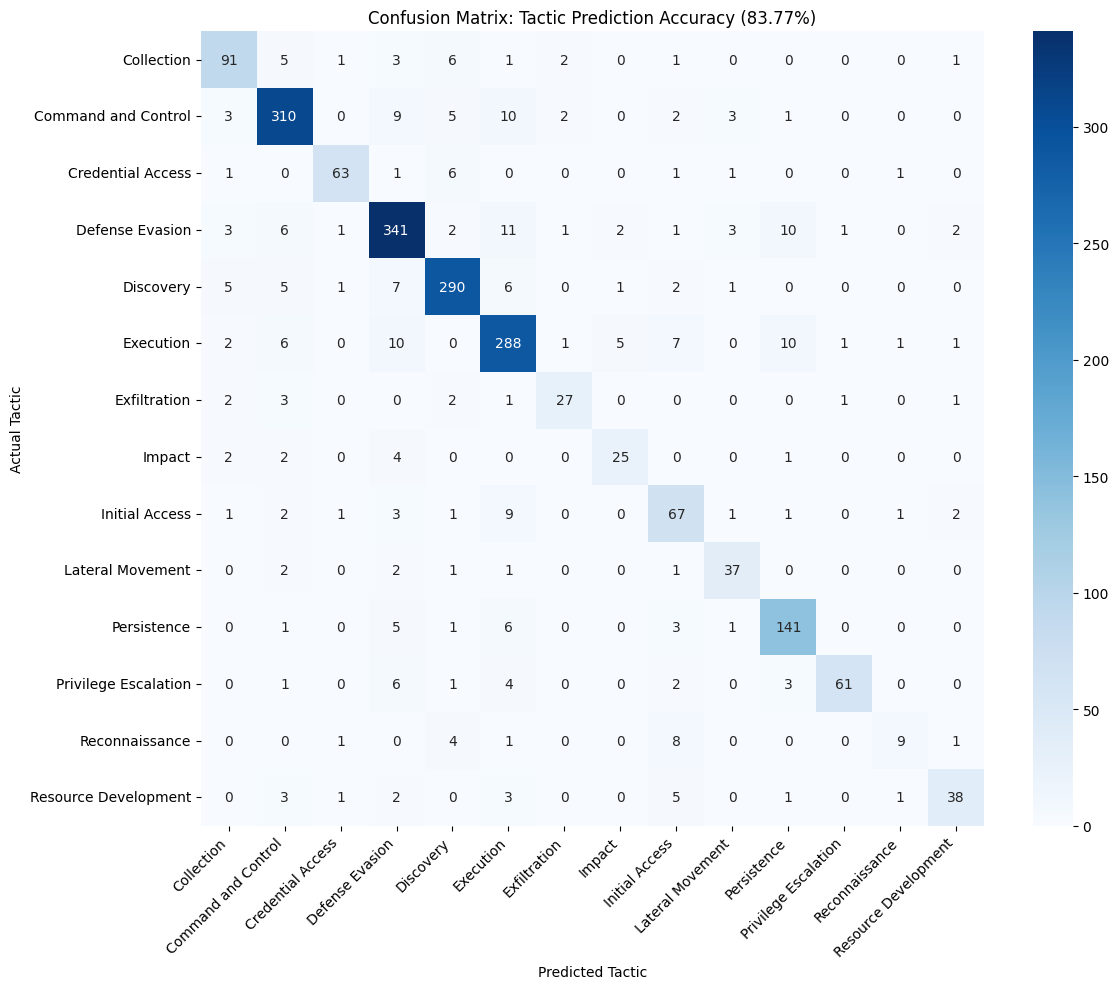


Detailed Classification Report:

                      precision    recall  f1-score   support

          Collection       0.83      0.82      0.82       111
 Command and Control       0.90      0.90      0.90       345
   Credential Access       0.91      0.85      0.88        74
     Defense Evasion       0.87      0.89      0.88       384
           Discovery       0.91      0.91      0.91       318
           Execution       0.84      0.87      0.86       332
        Exfiltration       0.82      0.73      0.77        37
              Impact       0.76      0.74      0.75        34
      Initial Access       0.67      0.75      0.71        89
    Lateral Movement       0.79      0.84      0.81        44
         Persistence       0.84      0.89      0.87       158
Privilege Escalation       0.95      0.78      0.86        78
      Reconnaissance       0.69      0.38      0.49        24
Resource Development       0.83      0.70      0.76        54

            accuracy              

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Generate the Confusion Matrix
# Use the y_true and y_pred from your previous validation step
cm = confusion_matrix(y_true, y_pred)
tactic_names = label_encoder.classes_

# 2. Plotting
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=tactic_names, 
            yticklabels=tactic_names)

plt.title('Confusion Matrix: Tactic Prediction Accuracy (83.77%)')
plt.ylabel('Actual Tactic')
plt.xlabel('Predicted Tactic')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Save the plot for your FYP report
plt.savefig("ttp_confusion_matrix.png")
plt.show()

# 3. Print the full classification report
# This gives you Precision, Recall, and F1 for EVERY single tactic
print("\nDetailed Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=tactic_names))

In [9]:
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F

print("Running validation data to build Calibration Map...")

# 1. Get raw predictions SPECIFICALLY from the validation dataset
val_outputs = trainer.predict(val_dataset)

# 2. Extract Confidence Scores and Predictions
probabilities = F.softmax(torch.tensor(val_outputs.predictions), dim=-1)
confidence_scores = torch.max(probabilities, dim=-1)[0].numpy()
predicted_ids = np.argmax(val_outputs.predictions, axis=-1)

# 3. Build a targeted DataFrame using your validation sentences
calibration_df = pd.DataFrame({
    'Sentence': val_texts,  # <--- Here are your validation questions!
    'Correct': predicted_ids == val_outputs.label_ids,
    'Confidence_Score': confidence_scores
})

# 4. Define the 10% buckets
bins = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
labels = ['0-10%', '11-20%', '21-30%', '31-40%', '41-50%', 
          '51-60%', '61-70%', '71-80%', '81-90%', '91-100%']

# 5. Assign each validation sentence to its corresponding bucket
calibration_df['Confidence_Bin'] = pd.cut(
    calibration_df['Confidence_Score'], 
    bins=bins, 
    labels=labels, 
    include_lowest=True
)

# 6. Calculate the statistics for each bucket
threshold_map = calibration_df.groupby('Confidence_Bin', observed=False).agg(
    Total_Sentences=('Correct', 'count'),       
    Correct_Predictions=('Correct', 'sum')      
).reset_index()

# 7. Calculate the actual accuracy mathematically
threshold_map['Actual_Accuracy'] = np.where(
    threshold_map['Total_Sentences'] > 0,
    (threshold_map['Correct_Predictions'] / threshold_map['Total_Sentences']) * 100,
    0
)

# Format for readability
threshold_map['Actual_Accuracy'] = threshold_map['Actual_Accuracy'].round(1).astype(str) + '%'

print("\n--- Validation Threshold Calibration Map ---")
display(threshold_map)

Running validation data to build Calibration Map...



--- Validation Threshold Calibration Map ---


,Confidence_Bin,Total_Sentences,Correct_Predictions,Actual_Accuracy
0,0-10%,0,0,0.0%
1,11-20%,4,1,25.0%
2,21-30%,39,15,38.5%
3,31-40%,69,29,42.0%
4,41-50%,61,26,42.6%
5,51-60%,87,50,57.5%
6,61-70%,94,55,58.5%
7,71-80%,151,105,69.5%
8,81-90%,701,650,92.7%
9,91-100%,876,857,97.8%


In [10]:
#### We can create a threshold where if the probabibly of this model predicting is lesser than something we will not pass this sentence to the next stage

import torch
import torch.nn.functional as F

def predict_question(sentences, trained_model, trained_tokenizer):
    """
    Takes a list of sentences, runs them through the Stage 1 model,
    and returns a list of dictionaries containing the predicted Tactic and Confidence.
    """
    results = []
    
    # Put the model in evaluation mode (turns off training-specific features like dropout)
    trained_model.eval()
    device = trained_model.device
    
    for sentence in sentences:
        # 1. Tokenize the sentence
        inputs = trained_tokenizer(sentence, return_tensors="pt", truncation=True, max_length=256)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        
        # 2. Get the model's raw output (logits) without calculating gradients to save memory
        with torch.no_grad():
            outputs = trained_model(**inputs)
            logits = outputs.logits
            
        # 3. Apply Softmax to get the percentages
        probabilities = F.softmax(logits, dim=-1)
        confidence_score, predicted_class_id = torch.max(probabilities, dim=-1)
        
        # 4. Extract the actual numbers and readable label
        conf_val = confidence_score.item()
        tactic_id = predicted_class_id.item()
        tactic_name = trained_model.config.id2label[tactic_id]
        
        # 5. Store the data
        results.append({
            "sentence": sentence,
            "tactic": tactic_name,
            "confidence": conf_val
        })
        
    return results

def parsing_confidence(predictions, threshold=0.80):
    """
    Filters the predictions. If >= threshold, it goes to Stage 2.
    If < threshold, it is flagged for manual review.
    """
    passed_for_stage_2 = []
    flagged_for_review = []
    
    for pred in predictions:
        if pred["confidence"] >= threshold:
            passed_for_stage_2.append(pred)
        else:
            flagged_for_review.append(pred)
            
    return passed_for_stage_2, flagged_for_review

In [ ]:
# 1. Grab a sample from your validation set to test the pipeline flow
# (Let's use the first 50 sentences so it doesn't flood your screen)
test_sentences = val_texts[:50]

# 2. Run the prediction function
print(f"Analyzing {len(test_sentences)} validation sentences...")
all_predictions = predict_question(test_sentences, model, tokenizer)

# 3. Route them through your confidence filter (Let's test an 80% threshold)
stage_2_ready, manual_review = parsing_confidence(all_predictions, threshold=0.80)

# 4. View the results summary
print(f"\n Sentences passing to Stage 2: {len(stage_2_ready)} / {len(test_sentences)}")
print(f" Sentences flagged for Manual Review: {len(manual_review)} / {len(test_sentences)}")

# 5. Look at a few examples of what passed vs. what failed
print("\n--- Example: Passed to Stage 2 ---")
for item in stage_2_ready[:3]:
    print(f"[{item['tactic']}] (Conf: {item['confidence']:.2%}) | {item['sentence'][:80]}...")

print("\n--- Example: Flagged for Review ---")
for item in manual_review[:3]:
    print(f"[{item['tactic']}] (Conf: {item['confidence']:.2%}) | {item['sentence'][:80]}...")

Analyzing 50 validation sentences...

✅ Sentences passing to Stage 2: 39 / 50
⚠️ Sentences flagged for Manual Review: 11 / 50

--- Example: Passed to Stage 2 ---
[Execution] (Conf: 92.66%) | EnvyScout can write files to disk with JavaScript using a modified version of th...
[Discovery] (Conf: 91.00%) | TrickBot searches the system for all of the following file extensions: .avi, .mo...
[Discovery] (Conf: 88.84%) | sets a WH_CBT Windows hook to search for and capture files on the victim....

--- Example: Flagged for Review ---
[Execution] (Conf: 35.50%) | In some cases, the encoded PowerShell commands were used to download and execute...
[Collection] (Conf: 45.18%) | We have identified several implants that leveraged PowerShell, VBS, JS, and dotn...
[Credential Access] (Conf: 69.68%) | APT29 created tokens using compromised SAML signing certificates....


In [ ]:
###pre-pipeline_model
from transformers import AutoModelForSequenceClassification, AutoTokenizer

load_model = "/kaggle/input/models/jamieteh/tactic-classification/pytorch/default/1"
model = AutoModelForSequenceClassification.from_pretrained(load_model)
tokenizer = AutoTokenizer.from_pretrained(load_model)


def tactic_classification():
    """
    This is where the model will be processing the question
    """
    ####the questions from evaluation
    model.predict()
    tokenizer
    confidence score